In [146]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from NanoparticlesSAM.particle_stats import *
from NanoparticlesSAM.particle_seg import *

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [147]:
foldername = 'results/20250228/'
pickels = glob.glob(f'{foldername}/*pkl')

df_list = []

for file in pickels:
    df_list.append(pd.read_pickle(file))

df = pd.concat(df_list)
#df['nm_per_pixel']  = df['nm_estimated_radius'] / df['estimated_radius']

In [148]:
df.head()

,segmentation,area,bbox,predicted_iou,point_coords,stability_score,crop_box,smooth_mask,perimeter,smooth_area,...,estimated_radius,point_coords_tuple,feret_diameter,min_feret_diameter,nm_feret_radius,nm_estimated_radius,nm_min_feret_diameter,img_name,experiment,nm_per_pixel
0,"[[False, False, False, False, False, False, Fa...",34271,"[525, 489, 213, 206]",1.005113,"[[588.5277777777778, 656.3611111111111]]",0.984400,"[477, 317, 803, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",853,34271.0,...,104.445192,"(588.5277777777778, 656.3611111111111)",218.277347,204.057510,121.143927,115.934163,226.503837,A4-2h-01,A4-2h,1.11
0,"[[False, False, False, False, False, False, Fa...",35006,"[532, 514, 212, 212]",0.993316,"[[543.9166666666666, 584.9166666666666]]",0.983653,"[477, 317, 803, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",857,35006.0,...,105.559253,"(543.9166666666666, 584.9166666666666)",219.020547,207.884079,121.556404,117.170771,230.751328,A4-2h-02,A4-2h,1.11
1,"[[False, False, False, False, False, False, Fa...",34344,"[451, 180, 218, 214]",1.001823,"[[558.3333333333333, 196.7777777777778]]",0.983394,"[0, 0, 804, 644]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",873,34346.0,...,104.556371,"(558.3333333333333, 196.7777777777778)",221.542321,204.182831,122.955988,116.057572,226.642942,A4-2h-02,A4-2h,1.11
2,"[[False, False, False, False, False, False, Fa...",34529,"[244, 139, 214, 215]",0.999405,"[[334.99999999999994, 304.1111111111111]]",0.983097,"[0, 0, 804, 644]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",863,34528.0,...,104.837599,"(334.99999999999994, 304.1111111111111)",216.748702,205.752945,120.295530,116.369734,228.385769,A4-2h-02,A4-2h,1.11
3,"[[False, False, False, False, False, False, Fa...",34426,"[309, 340, 211, 208]",1.012048,"[[334.99999999999994, 370.5833333333333]]",0.975442,"[0, 317, 804, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",881,34425.0,...,104.681116,"(334.99999999999994, 370.5833333333333)",229.839074,206.848206,127.560686,116.196039,229.601508,A4-2h-02,A4-2h,1.11


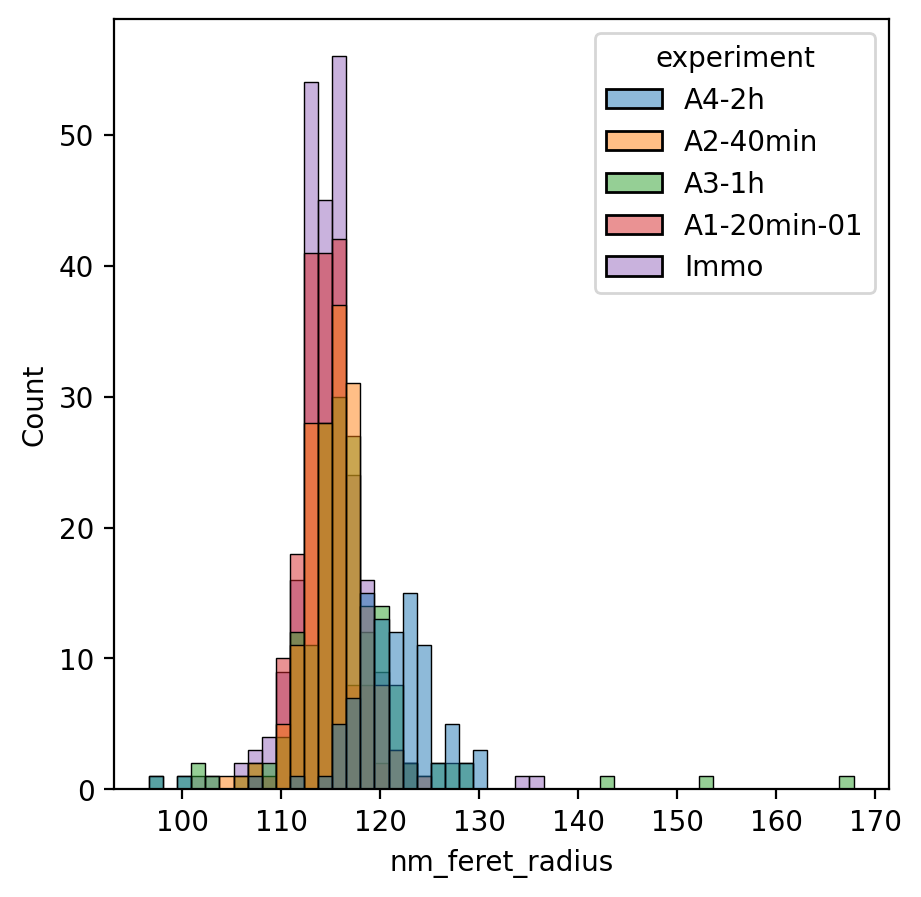

In [149]:
plt.figure(figsize=(5,5), dpi=200)
sns.histplot(data=df, x='nm_feret_radius', hue='experiment', bins=50)
plt.savefig(f'{foldername}/unfiltered_measurements')

In [161]:
exclusion_list = []

In [162]:
df_filtered = df[~df['img_name'].isin(exclusion_list)]

In [163]:
df_filtered['hough_radius'] = df_filtered.apply(lambda x: get_hough_radius(x['smooth_mask'], 
                                                                           dp=2, 
                                                                           nm_min_radius=70, 
                                                                           nm_max_radius=150, 
                                                                           nm_per_pixel=x['nm_per_pixel'], 
                                                                           convert_to_nm=True), axis=1)

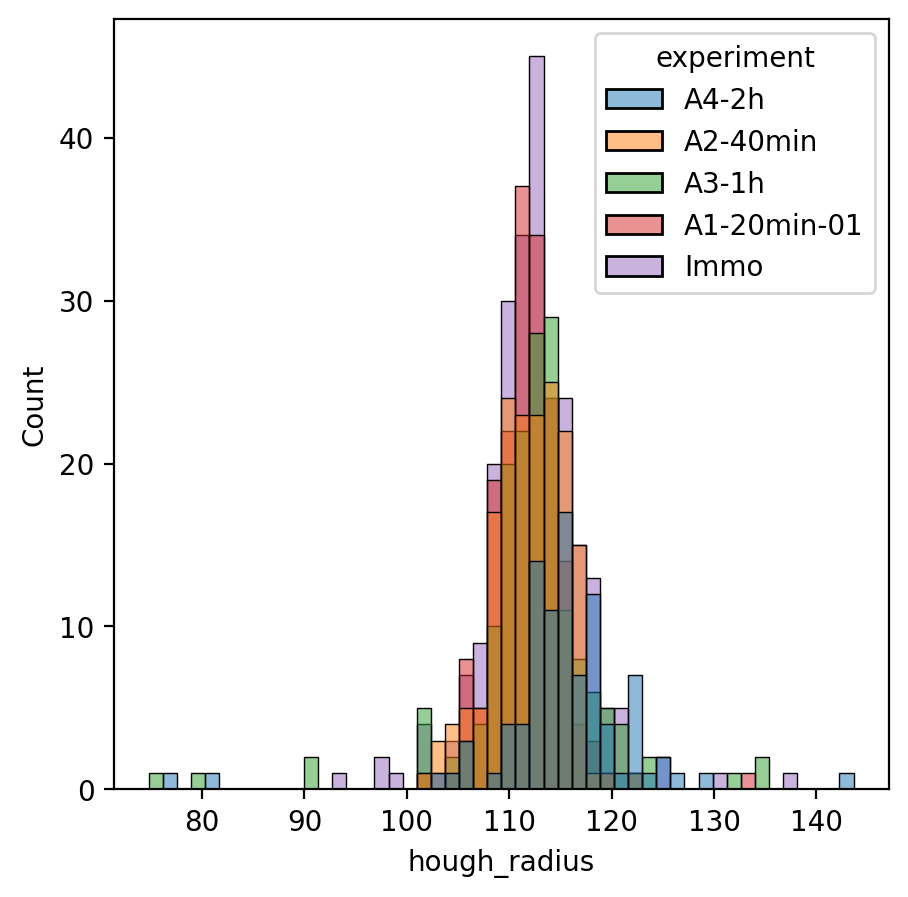

In [164]:
plt.figure(figsize=(5,5), dpi=200)

sns.histplot(data=df_filtered.dropna(), x='hough_radius', hue='experiment', bins=50)
plt.savefig(f'{foldername}/unfiltered_measurements')

In [169]:
filter_quantity =  'hough_radius' 
#filter_quantity = 'nm_feret_radius' 
q5, q95 = df_filtered[filter_quantity].quantile([0.05, 0.95])
df_filtered = df_filtered[(df_filtered[filter_quantity] < q95) & (df_filtered[filter_quantity] > q5)]

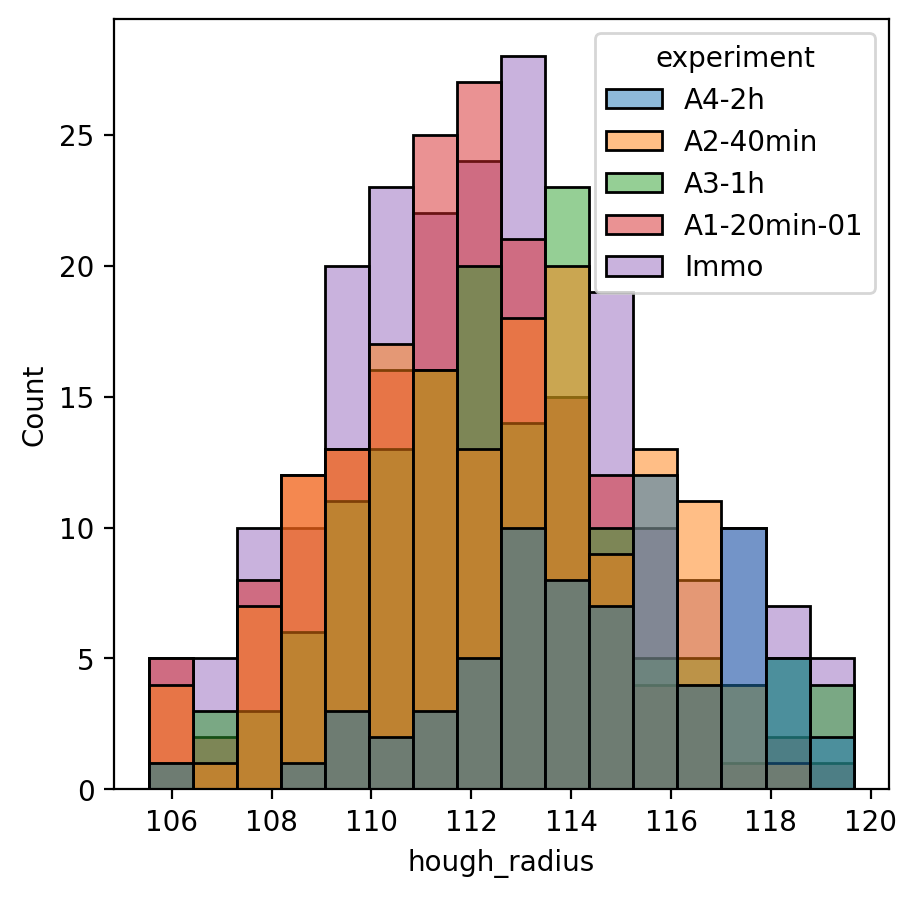

In [170]:
plt.figure(figsize=(5,5), dpi=200)
plot_df = df_filtered.dropna()
sns.histplot(data=plot_df, x=filter_quantity, hue='experiment')
plt.savefig(f'{foldername}/filtered_particle_measurements')

<Figure size 1000x1000 with 0 Axes>

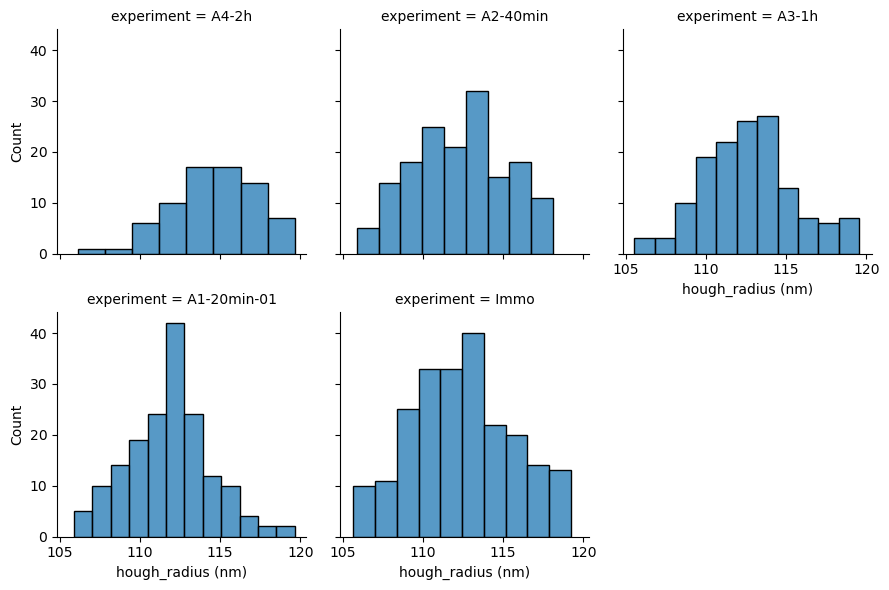

In [171]:
plt.figure(figsize=(5,5), dpi=200)
g = sns.FacetGrid(plot_df, col='experiment', col_wrap=3)
g.map(sns.histplot, filter_quantity)
g.set_axis_labels(f"{filter_quantity} (nm)", "Count")
plt.savefig(f'{foldername}/histogram-grid')

In [172]:
filter_quantity =  'hough_radius' 
#filter_quantity = 'nm_feret_radius' 
experiment_df = df_filtered.reset_index().pivot(columns='experiment', values=filter_quantity)
experiment_df = experiment_df.apply(lambda x: pd.Series(x.dropna().values))
#experiment_df = remove_outliers_df(experiment_df)
experiment_df.head()

experiment,A1-20min-01,A2-40min,A3-1h,A4-2h,Immo
0,113.441997,115.661997,113.220000,112.775998,112.775998
1,110.778003,106.338003,118.325998,113.441997,111.000000
2,109.001997,109.668003,113.441997,112.331997,119.214002
3,111.888003,109.445998,112.554002,114.774002,116.550000
4,113.441997,113.885998,108.114002,118.770000,109.668003


In [173]:
experiment_df.describe()

experiment,A1-20min-01,A2-40min,A3-1h,A4-2h,Immo
count,168.000000,159.000000,143.000000,73.000000,221.000000
mean,111.820607,112.311056,112.750140,114.667562,112.419321
std,2.607882,2.848992,2.837090,2.762171,3.113618
min,105.894002,105.894002,105.544001,106.115998,105.671997
25%,110.111997,110.111997,110.778003,112.998003,110.111997
50%,111.888003,112.554002,112.558003,114.774002,112.400002
75%,113.441997,114.330000,114.279001,116.550000,114.645996
max,119.658003,118.104002,119.571997,119.658003,119.214002


In [174]:
analysis_df = analyze_samples(experiment_df, 'Immo', alpha=0.1)
analysis_df.to_csv(f'{foldername}/analysis.csv')
analysis_df.to_excel(f'{foldername}/analysis.xlsx')
analysis_df

,A1-20min-01,A2-40min,A3-1h,A4-2h
thickness,-0.598714,-0.108265,0.330818,2.24824
CI_lower,-1.077586,-0.616337,-0.191229,1.610329
CI_upper,-0.119842,0.399807,0.852865,2.886151
p_value,0.039931,0.725485,0.296651,0.0
significance,Significant,Not significant,Not significant,Significant
significance_level,95.0,95.0,95.0,95.0
SEM,0.29043,0.308084,0.316472,0.385204
DOF,383.337488,356.927895,322.966816,137.212778
N_sample,168,159,143,73
N_ref,221,221,221,221


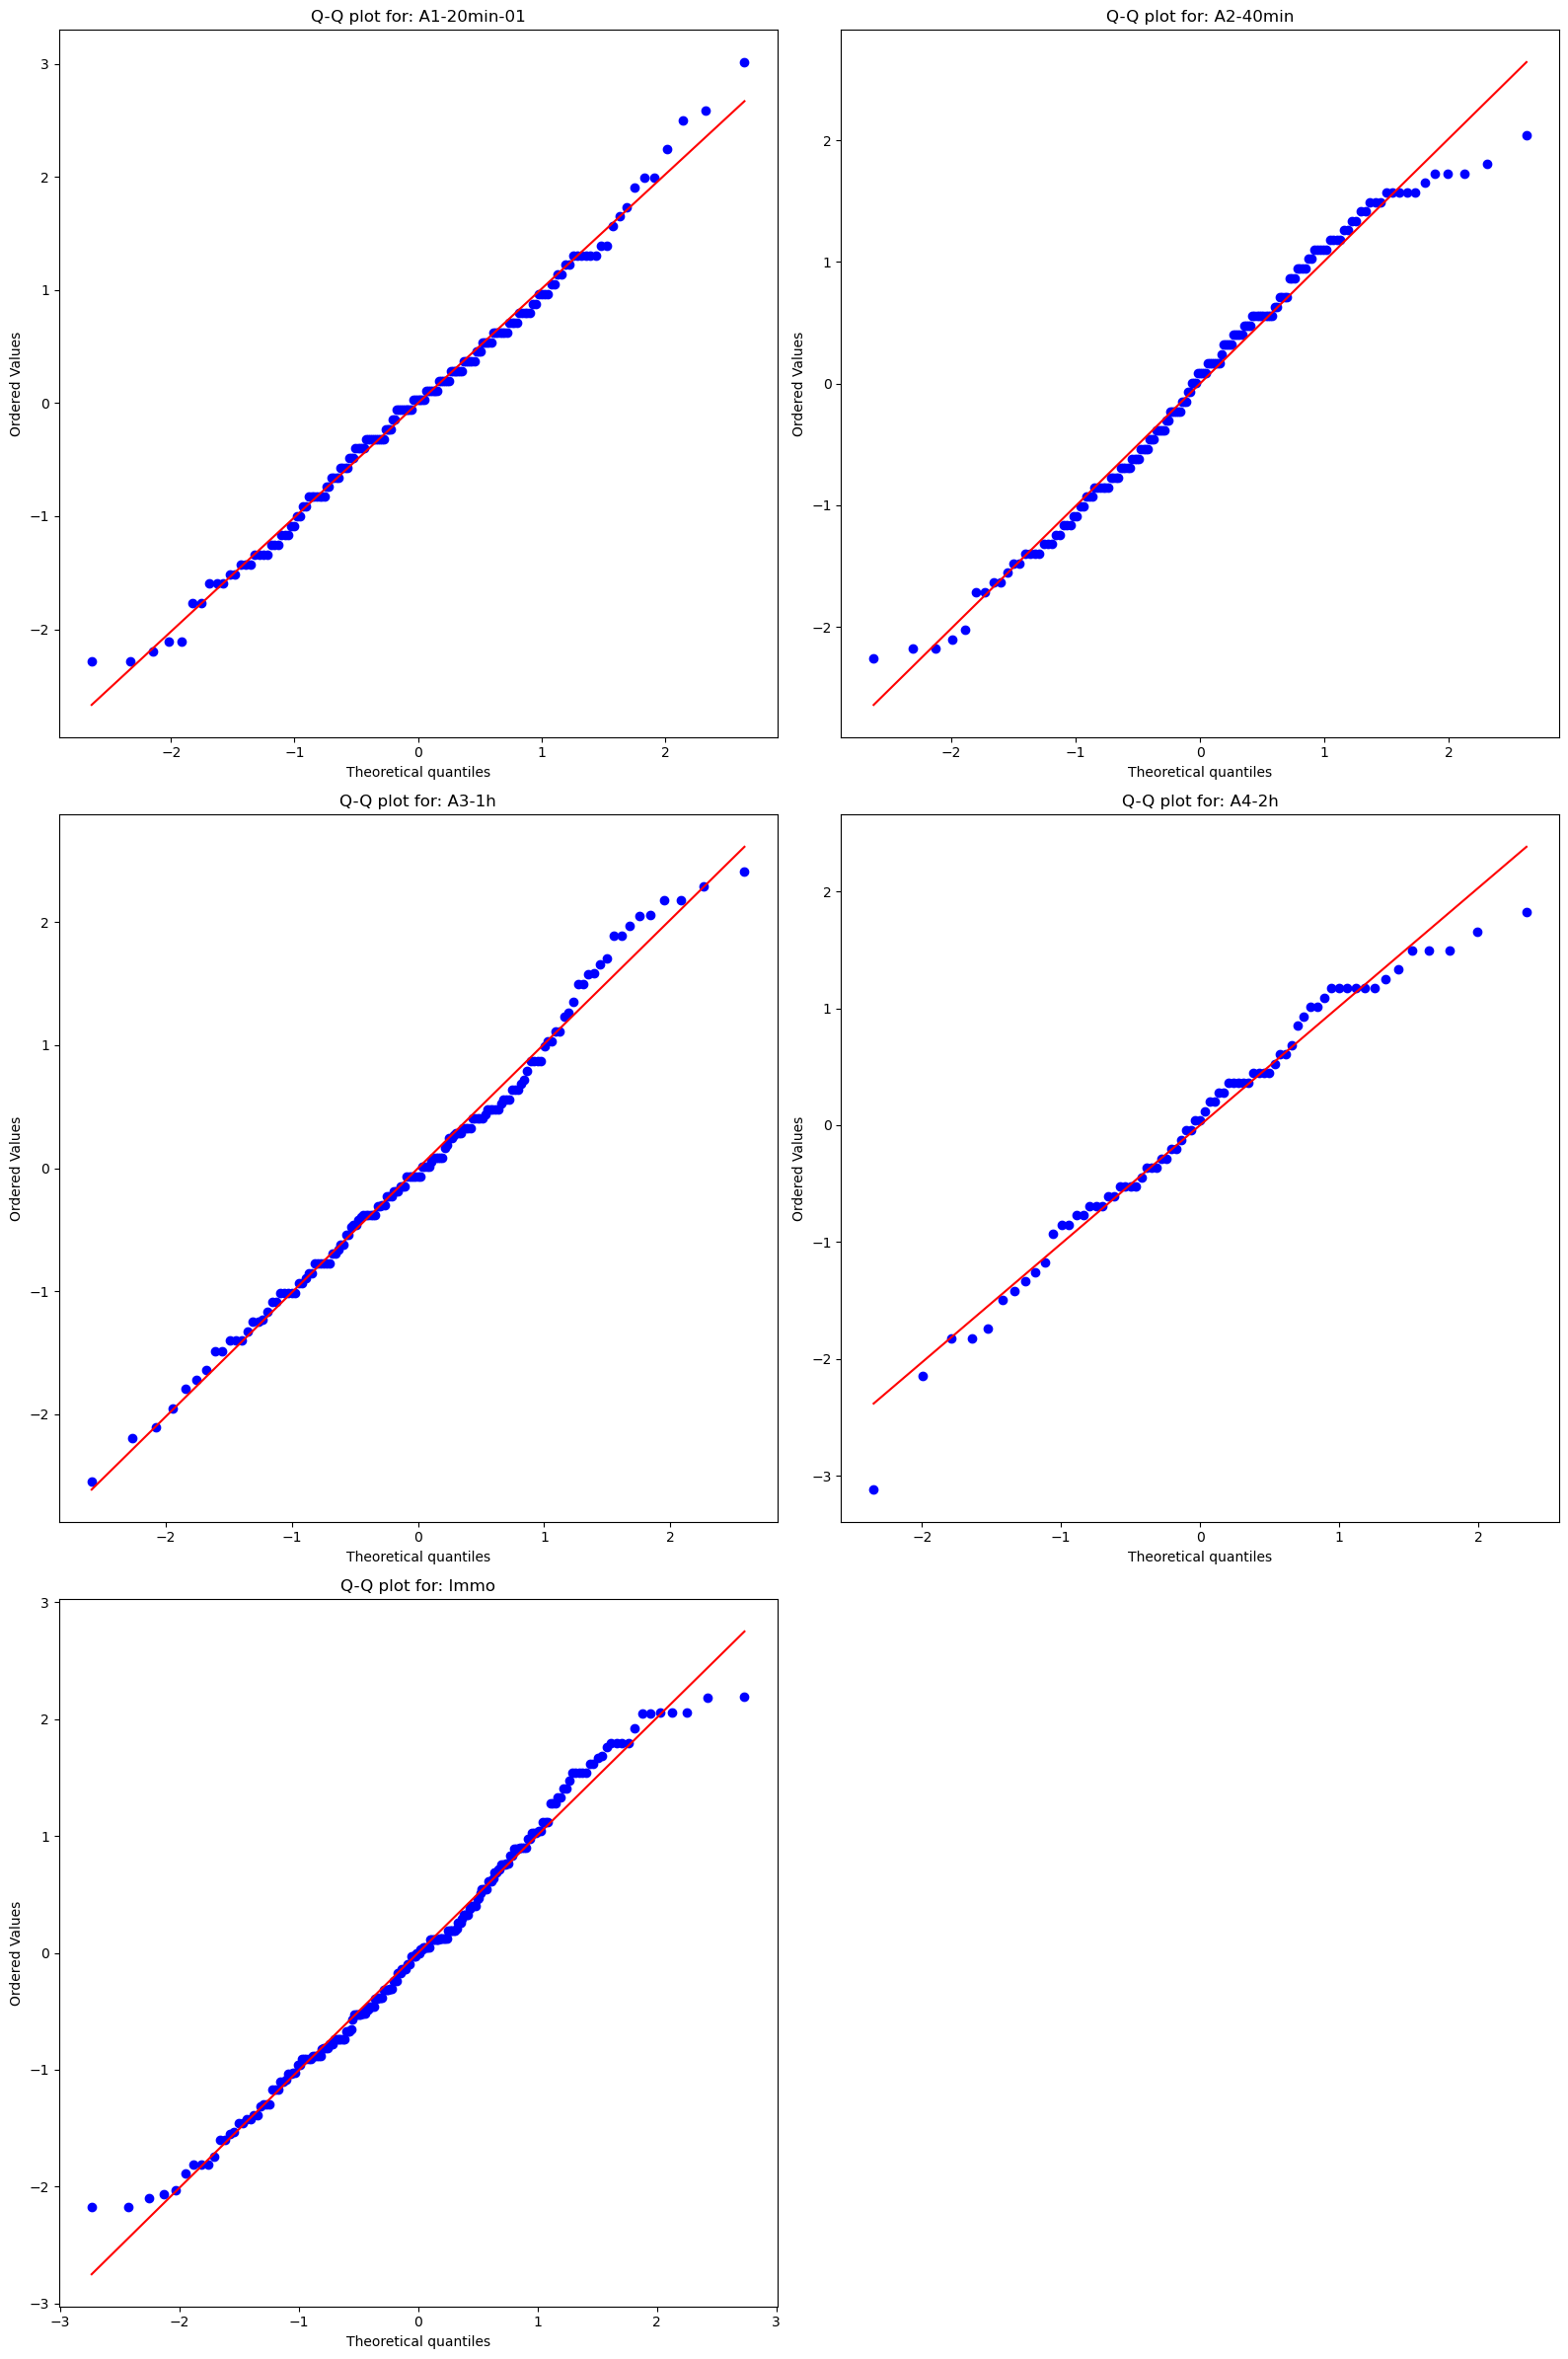

<Figure size 640x480 with 0 Axes>

In [175]:
plot_quantiles(experiment_df, foldername)
